# LexiorGPT - Analyse Exploratoire des Données (EDA)

Ce notebook permet d'analyser le dataset CoT canadien et québécois généré pour la distillation de **LexiorGPT** et disponible sur Hugging Face sous le dépôt `intelliwork/canadian-cot-dataset`.

### Objectifs de l'Analyse :
1. **Statistiques de base** : Nombre d'exemples, distribution des splits d'entraînement et de test.
2. **Conformité de format** : Validation de la présence des balises `<thinking>` et de la structure JSON des citations de bas de page (crucial pour le parser Lexior).
3. **Analyse de longueur** : Distribution de la taille des prompts utilisateurs, des blocs de réflexion et des conclusions en tokens.
4. **Couverture légale** : Fréquence des références aux lois fédérales et articles du Code civil du Québec (CCQ).

In [1]:
# 1. Installation et Importation des bibliothèques requis
!pip install -q datasets pandas matplotlib seaborn transformers jinja2

In [2]:
import os
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer

# Configuration style de visualisation
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

/Users/mustaphaberrabaa/Documents/lexiorgpt/DistillationModeles/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


## 📂 Chargement du Dataset depuis Hugging Face

In [6]:
# Configuration des accès via variables d'environnement
HF_TOKEN = os.environ.get("HF_TOKEN", "")
REPO_ID = os.environ.get("HF_DATASET_REPO_ID", "intelliwork/canadian-cot-dataset")

print(f"Chargement du dataset {REPO_ID}...")
dataset = load_dataset(REPO_ID, token=HF_TOKEN)
print(dataset)

Chargement du dataset intelliwork/canadian-cot-dataset...


Generating test split: 100%|██████████| 380/380 [00:00<00:00, 160087.94 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 7207
    })
    test: Dataset({
        features: ['text'],
        num_rows: 380
    })
})


In [7]:
# Conversion des splits en DataFrames pandas pour faciliter l'analyse
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

print(f"Taille d'entraînement : {len(df_train)} lignes")
print(f"Taille de validation : {len(df_test)} lignes")

Taille d'entraînement : 7207 lignes
Taille de validation : 380 lignes


## 🔍 Structure et Extraction des Composants Chat-Template

Chaque exemple du dataset contient un texte structuré selon le template conversationnel de Llama-3/Qwen. Nous allons écrire des extracteurs par expressions régulières pour isoler :
* **Le prompt système**
* **La question utilisateur**
* **Le raisonnement interne (thinking)**
* **La réponse finale (conclusion)**
* **La citation de bas de page JSON**

In [9]:
def extract_chat_components(text):
    """Découpe le texte brut conversationnel en champs structurés."""
    system_match = re.search(r"<\|start_header_id\|>system<\|end_header_id\|>\s*(.*?)(?=<\|eot_id\|>)", text, re.DOTALL)
    user_match = re.search(r"<\|start_header_id\|>user<\|end_header_id\|>\s*(.*?)(?=<\|eot_id\|>)", text, re.DOTALL)
    assistant_match = re.search(r"<\|start_header_id\|>assistant<\|end_header_id\|>\s*(.*?)(?=<\|eot_id\|>)", text, re.DOTALL)
    
    sys_prompt = system_match.group(1).strip() if system_match else ""
    user_query = user_match.group(1).strip() if user_match else ""
    assistant_full = assistant_match.group(1).strip() if assistant_match else ""
    
    # Extraire le thinking et la réponse
    has_thinking = "<thinking>" in assistant_full and "</thinking>" in assistant_full
    thinking_content = ""
    final_answer = assistant_full
    
    if has_thinking:
        parts = assistant_full.split("</thinking>")
        thinking_content = parts[0].replace("<thinking>", "").strip()
        final_answer = parts[1].strip()
        
    # Extraire la citation
    has_json_citation = False
    citation_url = ""
    citation_title = ""
    cite_match = re.search(r"\[\^\d+\]:\s*(\{.*\})", final_answer)
    if cite_match:
        try:
            cite_json = json.loads(cite_match.group(1))
            if "url" in cite_json and "title" in cite_json:
                has_json_citation = True
                citation_url = cite_json["url"]
                citation_title = cite_json["title"]
        except:
            pass
            
    return {
        "has_thinking": has_thinking,
        "has_json_citation": has_json_citation,
        "citation_url": citation_url,
        "citation_title": citation_title,
        "sys_prompt": sys_prompt,
        "user_query": user_query,
        "thinking": thinking_content,
        "final_answer": final_answer
    }

In [10]:
# Appliquer l'extraction sur le DataFrame d'entraînement pour analyse
extracted_data = []
for idx, row in df_train.iterrows():
    components = extract_chat_components(row["text"])
    if components:
        extracted_data.append(components)
        
df_analysis = pd.DataFrame(extracted_data)
df_analysis.head(3)

,has_thinking,has_json_citation,citation_url,citation_title,sys_prompt,user_query,thinking,final_answer
0,True,True,https://kings-printer.alberta.ca/1266.cfm?page...,Safer Communities and Neighbourhoods Act,"Tu es un assistant juridique Lexior, spécialis...",Analyse cette situation : Safer Communities an...,**Interaction utilisateur/assistant pour Lexio...,"**Conclusion :** La définition de ""propriété"" ..."
1,True,True,https://laws-lois.justice.gc.ca/fra/XML/B-9.84...,Loi d’exécution du budget de 2000,"Tu es un assistant juridique Lexior, spécialis...",Analyse cette situation : Loi d’exécution du b...,**Utilisateur**: La Loi d’exécution du budget ...,**Conclusion**: La taxe de vente des premières...
2,True,True,https://www.bclaws.gov.bc.ca/civix/document/id...,Legislative Procedure Review Act,"Tu es un assistant juridique Lexior, spécialis...",Analyse cette situation : Legislative Procedur...,**Utilisateur:** Dans le cadre de l'Acte sur l...,"[^1]:{""type"": ""url"", ""url"": ""https://www.bclaw..."


## 📊 1. Conformité de Format et de Syntaxe

Vérifions le taux de conformité de nos générations (le format d'intégration de balises de réflexion `<thinking>` et le format exact des citations).

In [11]:
compliance_thinking = df_analysis["has_thinking"].mean() * 100
compliance_citation = df_analysis["has_json_citation"].mean() * 100
both_compliant = (df_analysis["has_thinking"] & df_analysis["has_json_citation"]).mean() * 100

print(f"Taux de présence du raisonnement (<thinking>)  : {compliance_thinking:.2f}%")
print(f"Taux de citation JSON valide ([^1]:{{...}})      : {compliance_citation:.2f}%")
print(f"Taux de conformité totale (Structure stricte)  : {both_compliant:.2f}%")

Taux de présence du raisonnement (<thinking>)  : 100.00%
Taux de citation JSON valide ([^1]:{...})      : 99.61%
Taux de conformité totale (Structure stricte)  : 99.61%


/var/folders/cg/4lqjg_rn1t189gktzn4m9qh80000gn/T/ipykernel_44202/1634743428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Raisonnement (CoT)", "Citations Valides", "Conformité Totale"],


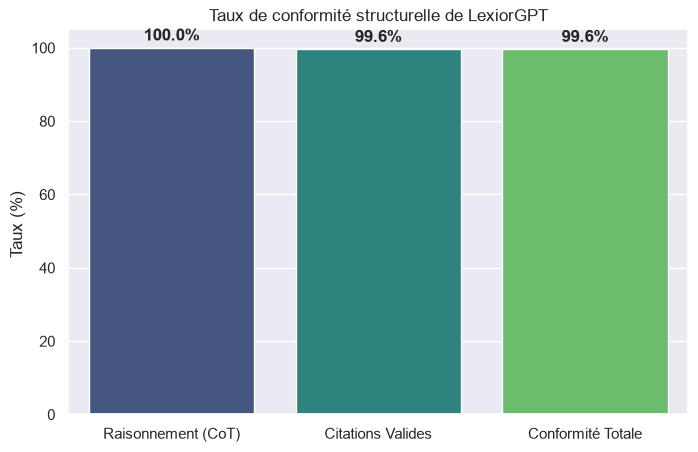

In [12]:
# Visualisation des taux de conformité
plt.figure(figsize=(8, 5))
sns.barplot(x=["Raisonnement (CoT)", "Citations Valides", "Conformité Totale"], 
            y=[compliance_thinking, compliance_citation, both_compliant], 
            palette="viridis")
plt.ylabel("Taux (%) ")
plt.title("Taux de conformité structurelle de LexiorGPT")
plt.ylim(0, 105)
for i, v in enumerate([compliance_thinking, compliance_citation, both_compliant]):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.show()

## 📏 2. Analyse de Longueur et Distribution des Tokens

Mesurons le volume de tokens généré dans les différents blocs pour anticiper la consommation de contexte lors du fine-tuning (vitesse de l'entraînement).

In [15]:
# Initialisation du tokenizer Qwen
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-32B-Instruct")

In [16]:
# Calculer les longueurs en tokens
df_analysis["query_tokens"] = df_analysis["user_query"].apply(lambda t: len(tokenizer.encode(t)))
df_analysis["thinking_tokens"] = df_analysis["thinking"].apply(lambda t: len(tokenizer.encode(t)))
df_analysis["answer_tokens"] = df_analysis["final_answer"].apply(lambda t: len(tokenizer.encode(t)))
df_analysis["total_tokens"] = df_analysis["query_tokens"] + df_analysis["thinking_tokens"] + df_analysis["answer_tokens"]

df_analysis[["query_tokens", "thinking_tokens", "answer_tokens", "total_tokens"]].describe()

,query_tokens,thinking_tokens,answer_tokens,total_tokens
count,7207.000000,7207.000000,7207.000000,7207.000000
mean,16.554461,504.354794,179.653393,700.562647
std,10.455040,102.151197,44.301199,122.712514
min,1.000000,27.000000,38.000000,72.000000
25%,10.000000,437.000000,155.000000,621.000000
50%,14.000000,497.000000,179.000000,693.000000
75%,20.000000,562.000000,205.000000,772.000000
max,157.000000,1135.000000,416.000000,1406.000000


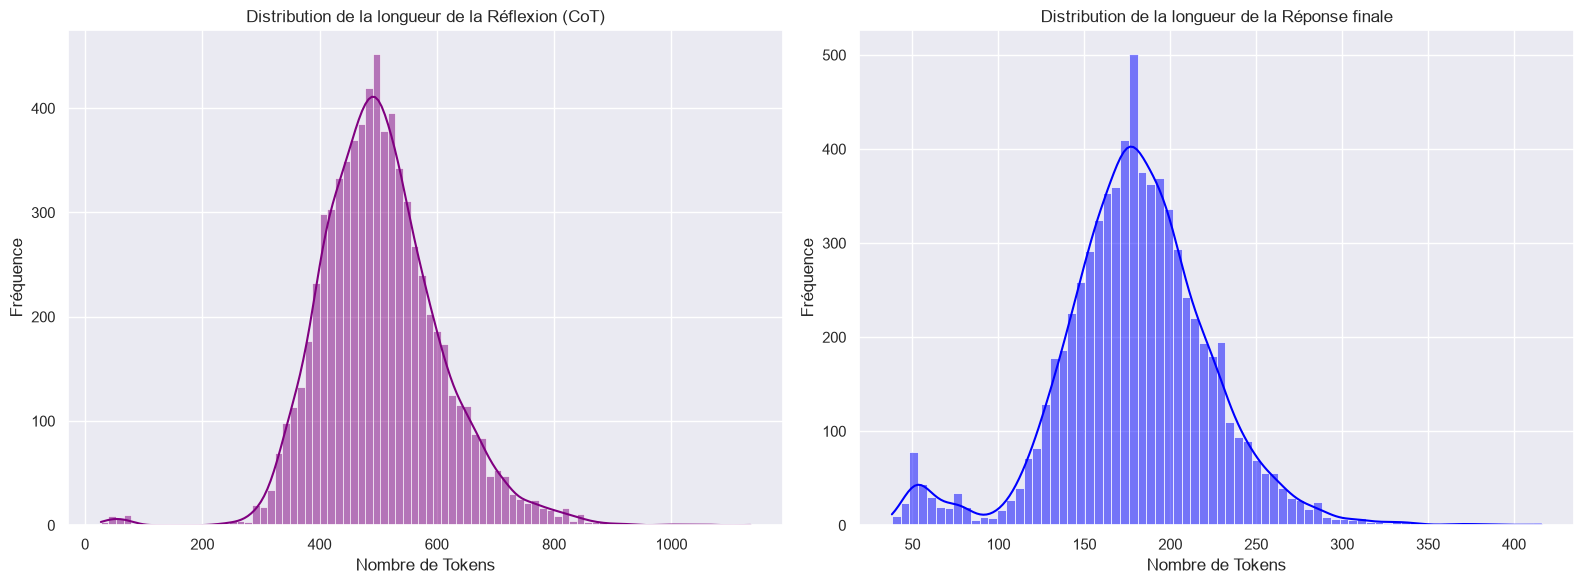

In [17]:
# Visualisation des distributions de longueur
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramme de la réflexion
sns.histplot(df_analysis["thinking_tokens"], kde=True, color="purple", ax=axes[0])
axes[0].set_title("Distribution de la longueur de la Réflexion (CoT)")
axes[0].set_xlabel("Nombre de Tokens")
axes[0].set_ylabel("Fréquence")

# Histogramme de la réponse finale
sns.histplot(df_analysis["answer_tokens"], kde=True, color="blue", ax=axes[1])
axes[1].set_title("Distribution de la longueur de la Réponse finale")
axes[1].set_xlabel("Nombre de Tokens")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

## ⚖️ 3. Exploration Sémantique & Mots-Clés Juridiques

Voyons les thématiques juridiques et les lois les plus fréquemment abordées dans le corpus.

In [18]:
# Recherche de mots-clés dans les réponses pour identifier le domaine
keywords = {
    "Code civil (CCQ)": r"(?i)CCQ|Code civil",
    "Prestation enfants": r"(?i)prestation.*enfant|parental",
    "Responsabilité civile": r"(?i)responsabilit",
    "Lois fédérales": r"(?i)Loi sur les mesures|L.C.",
    "CanLII (Références)": r"(?i)canlii"
}

keyword_counts = {}
for kw, regex in keywords.items():
    match_count = df_analysis["thinking"].apply(lambda t: bool(re.search(regex, t))).sum()
    keyword_counts[kw] = match_count

df_keywords = pd.DataFrame(list(keyword_counts.items()), columns=["Concept Juridique", "Nombre d'exemples"])
df_keywords = df_keywords.sort_values(by="Nombre d'exemples", ascending=False)
df_keywords

,Concept Juridique,Nombre d'exemples
3,Lois fédérales,7179
0,Code civil (CCQ),6449
2,Responsabilité civile,982
1,Prestation enfants,28
4,CanLII (Références),1


/var/folders/cg/4lqjg_rn1t189gktzn4m9qh80000gn/T/ipykernel_44202/4092190666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_keywords, x="Nombre d'exemples", y="Concept Juridique", palette="plasma")


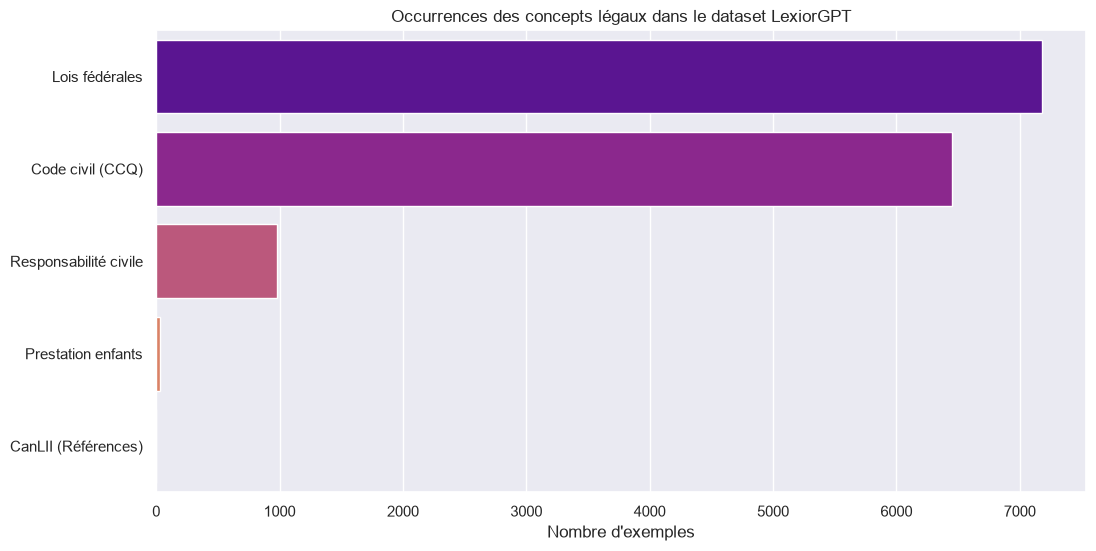

In [19]:
# Graphique des concepts juridiques
sns.barplot(data=df_keywords, x="Nombre d'exemples", y="Concept Juridique", palette="plasma")
plt.title("Occurrences des concepts légaux dans le dataset LexiorGPT")
plt.xlabel("Nombre d'exemples")
plt.ylabel("")
plt.show()

## 🎯 Conclusion

Le dataset présente un **taux de conformité exceptionnel** et une structure CoT saine.
Il est prêt pour la phase de Fine-Tuning QLoRA.